<a href="https://colab.research.google.com/github/raz0208/Natural-Language-Processing-Practices/blob/main/TopicModelling/EmbeddingsAnalysis_TopicClustring_BERTopic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Topic Modelling And Clustering**
### **Topic modelling by embedding vector space with **all-MiniLM-L6-v2****

In this notebook Turftopics library used for topic modelling and clustering. Turftopic is a topic modeling library which intends to simplify and streamline the usage of contextually sensitive topic models. We provide stable, minimal and scalable implementations of several types of models along with extensive documentation.

**SentenceTransformer:** This is a class from the sentence_transformers module, which is part of the sentence-transformers Python library. This class provides functionality to convert sentences or text passages into numerical representations (vectors) using pre-trained transformer models.

The **"all-MiniLM-L6-v2"** is a sentence-transformers model: It maps sentences & paragraphs to a 384 dimensional dense vector space and can be used for tasks like clustering or semantic search.

By initializing the SentenceTransformer model with the identifier "all-MiniLM-L6-v2", you're creating an instance of the SentenceTransformer class that is loaded with the specified pre-trained model. This model can then be used to encode or embed sentences into fixed-dimensional vectors, which can be useful for tasks such as semantic similarity comparison, clustering, or classification.


---




## **Step 1: Install packages and required libraries**


---

This step sets up the environment by installing necessary packages and importing relevant libraries.

In [ ]:
# Install libraries and packages
!pip install 'turftopic[umap-learn, datamapplot]'

In [2]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# Import topic clustring required libraries
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
from turftopic import Top2Vec
from turftopic import BERTopic

# Required libraries for dendrogram and visualisation
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluating libraries
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.cluster import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances
from scipy.spatial.distance import pdist

# Import Topic Namer library
from turftopic.namers import LLMTopicNamer

# Google drive library
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Step 2: Load and read original dataset**


---

In this step, the dataset is loaded from Google Drive or Google Colab root (or any other online coding platform). The dataset is a sample drived from original source which consists of 10,000 PubMed abstracts with accompanying metadata like title and year. This dataset downloaded from a Graph Database source.

### Several methods used to load and read dataset:
 - Google Drive files
 - Google Colab root files

In [3]:
# Read and Load dataset
dataset = pd.read_csv('/content/drive/MyDrive/Internship/Datasets/SampleDataset/sample_PubMedDataAbstracts.csv')

# Show the datasets
### Abstract Embeddings Sample Dataset
print('Node Content:', dataset.shape)
print(dataset)

Node Content: (10000, 4)
      Unnamed: 0                                              title  \
0              0  Phenotypic variability of Niemann-Pick disease...   
1              1  Recurrent hypoglycemia secondary to metformin ...   
2              2  Adaptation of the Ambulatory and Home Care Rec...   
3              3  Multidimensional family therapy in adolescents...   
4              4  Balanced crystalloids versus isotonic saline i...   
...          ...                                                ...   
9995        9995  Methylmercury in Industrial Harbor Sediments i...   
9996        9996  Factors Affecting Secondhand Smoke Avoidance B...   
9997        9997  Predicting Infectious Disease Using Deep Learn...   
9998        9998  Diosgenin Glucoside Protects against Spinal Co...   
9999        9999  Omics Approaches for Engineering Wheat Product...   

                                               abstract  year  
0     Background Niemann-Pick disease type C (NPC) i...  2

In [4]:
# Extract only the 'abstract' column and drop others
abstracts = dataset['abstract'].dropna().reset_index(drop=True)

# Display a few samples to verify
print(abstracts)

0       Background Niemann-Pick disease type C (NPC) i...
1       Background Metformin toxicity is well known to...
2       Background Measuring service use and costs is ...
3       Background Substance use and delinquency are c...
4       Objectives Intravenous fluids are one of the m...
                              ...                        
9995    The distribution of methylmercury (MeHg) and t...
9996    The purpose of this study was to examine the s...
9997    Infectious disease occurs when a person is inf...
9998    Spinal cord injury (SCI) is a severe traumatic...
9999    Abiotic stresses greatly influenced wheat prod...
Name: abstract, Length: 10000, dtype: object


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10000 non-null  int64 
 1   title       10000 non-null  object
 2   abstract    10000 non-null  object
 3   year        10000 non-null  object
dtypes: int64(1), object(3)
memory usage: 312.6+ KB


## **Step 3: Extract Embeddings using all-MiniLM-L6-v2**

---

In [ ]:
# Using TurfTopic default encoder to extract embedding of the dataset
encoder = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = encoder.encode(abstracts, show_progress_bar=True)

In [19]:
# Show embeddings matrix and Check the dimention of each eambeding
print(embeddings,"\n\n", embeddings.shape)

[[-0.06247491 -0.06421211 -0.04776807 ...  0.05779283 -0.00046217
  -0.0348533 ]
 [ 0.03635849 -0.05012973 -0.0077231  ... -0.00230364  0.01381705
  -0.08019841]
 [ 0.01247236  0.01453279 -0.01938152 ...  0.00787823  0.01995303
  -0.02415804]
 ...
 [-0.00543451 -0.08347747  0.03953594 ... -0.01684228 -0.10415071
   0.11270402]
 [-0.06943101 -0.0625765  -0.00057785 ...  0.00205806  0.01154448
  -0.04431521]
 [-0.07437815  0.00144461 -0.0106479  ... -0.01505966 -0.03949417
  -0.08860712]] 

 (10000, 384)


## **Step 4: Topic Modelling And Clustering by Vec2Top default model**

---

In [ ]:
# Training model (Uses HDBSCAN and umap)
model = Top2Vec(encoder=encoder, random_state=42)
topic_data = model.prepare_topic_data(abstracts, embeddings=embeddings)

In [21]:
# Topics data info
topic_data

TopicData
├── corpus (10000,)
├── vocab (10027,)
├── document_term_matrix (10000, 10027)
├── topic_term_matrix (97, 10027)
├── document_topic_matrix (10000, 97)
├── document_representation (10000, 384)
├── transform
├── topic_names (97)
├── has_negative_side
└── hierarchy

In [22]:
# Print Vec2Top extracted topics clusters
model.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                                      ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ metabolomic, metabolomics, biomarkers, proteomics, biomarker, proteomic, pharmacologically,          │
│          │ pharmacological, pharmacology, metabolome                                                            │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        0 │ retinopathy, retinal, intraocular, glaucoma, cataract, ocular, retina, ophthalmic, corneal, macular  │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        1 │ dental, periodontitis, periodontal, tooth, teeth, oral, dent, maxillary, enamel, gingival            │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        2 │ judgments, integrity, ethics, inherent, normative, judgment, moral, interpretation, interpretations, │
│          │ necessitates                                                                                         │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        3 │ pollutants, epidemiology, pollution, epidemiological, epidemiologic, pollutant, asthma, polluted,    │
│          │ toxicity, inhaled                                                                                    │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        4 │ microscopy, microscope, fluorescence, immunofluorescence, imaging, subcellular, proteomics,          │
│          │ intracellular, intercellular, multicellular                                                          │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        5 │ ligands, ligand, synthesized, compounds, synthesis, molecule, catalysis, molecular, aromatic,        │
│          │ catalyzed                                                                                            │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        6 │ sensor, sensing, sensors, gps, accelerometers, iot, accelerometer, monitoring, tracking, 802         │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        7 │ classifiers, cnn, classifying, classifier, classification, classify, supervised, bioinformatics,     │
│          │ biomarker, neural                                                                                    │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        8 │ hydroxyapatite, biomaterials, biomaterial, hydrogels, osteogenic, osteoblasts, osteoclasts,          │
│          │ biosynthetic, bioactivities, biocompatibility                                                        │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        9 │ biosensors, biosensor, nanoparticle, nanoparticles, nanotechnology, biomolecules,                    │
│          │ immunofluorescence, nanomaterials, biochemical, biomarkers                                           │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       10 │ nanoparticles, nanoparticle, nanotechnology, nanocrystals, nanomaterials, biomolecules,              │
│          │ nanocomposite, nanostructures, cytosol, pha

In [23]:
# Cluster model hierarchy visualisation
model.hierarchy.cut(3).plot_tree()

In [24]:
# Merging topics to reduce number of topics
model.reduce_topics(n_reduce_to=25)
print(model.hierarchy.cut(3))

Root: 
├── -1: metabolomic, metabolomics, biomarkers, proteomics, biomarker, proteomic, pharmacologically, 
│   pharmacological, 
│   pharmacology, metabolome
├── 6: sensor, sensing, sensors, gps, accelerometers, iot, accelerometer, monitoring, tracking, 
│   802
├── 34: probiotics, microbiome, probiotic, microbiomes, microbiota, microbiological, lactobacillus, 
│   dietary, microbial,
│   colitis
├── 45: phytochemical, phytochemicals, flavonoids, antioxidants, antioxidant, antioxidative, 
│   metabolites, phenolics, 
│   flavonoid, herbal
├── 107: tumour, malignancy, malignancies, tumor, neoplasia, tumors, carcinomas, carcinoma, tumours,
│   radiological
│   ├── 60: hepatic, hepatocellular, hepatitis, hepatocytes, hepatoprotective, hepatotoxicity, 
│   │   hepatocyte, hepatoma, 
│   │   cirrhosis, liver
│   └── 106: tumour, tumor, malignancy, malignancies, neoplasia, tumors, carcinomas, tumours, 
│       radiological, metastasis
│       ├── 68: lymphoma, myeloma, leukemia, malignancie

In [25]:
# Model hierarchy after merging topics visualisation
fig = model.hierarchy[152].plot_tree()
fig.show()

In [26]:
model.print_topic_distribution("cognitive neuroscience imaging")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Topic name                                                        ┃ Score ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ 151_neurophysiological_hippocampal_hippocampus_pathophysiological │  1.62 │
│ 131_cognition_neurocognitive_stimuli_cognitive                    │  1.55 │
│ 140_biosensor_biosensors_spectrometer_nanometer                   │  1.15 │
│ 166_intravascular_cerebrovascular_microvascular_indications       │  1.09 │
│ 163_genes_transcriptomics_epigenetics_micrornas                   │  1.09 │
│ 124_bioinformatics_proteomics_genomics_biomarker                  │  1.08 │
│ 107_tumour_malignancy_malignancies_tumor                          │  1.07 │
│ 6_sensor_sensing_sensors_gps                                      │  1.04 │
│ 164_nanomaterials_nanostructures_nanocrystals_nanostructured      │  1.03 │
│ -1_metabolomic_metabolomics_biomarkers_proteomics                 │  1.03 │
└───────────────────────────────────────────────────────────────────┴───────┘

In [27]:
# # We will reset the hierarchy, so that we can see all topics at once.
# model.reset_topics()
# fig = model.plot_clusters_datamapplot(hover_text=dataset["title"])
# fig.show()

## **Step 5: Topic Modelling And Clustering by BERTopic default model**

In [28]:
# Show embeddings matrix and Check the dimention of each eambeding
print(embeddings,"\n\n", embeddings.shape)

[[-0.06247491 -0.06421211 -0.04776807 ...  0.05779283 -0.00046217
  -0.0348533 ]
 [ 0.03635849 -0.05012973 -0.0077231  ... -0.00230364  0.01381705
  -0.08019841]
 [ 0.01247236  0.01453279 -0.01938152 ...  0.00787823  0.01995303
  -0.02415804]
 ...
 [-0.00543451 -0.08347747  0.03953594 ... -0.01684228 -0.10415071
   0.11270402]
 [-0.06943101 -0.0625765  -0.00057785 ...  0.00205806  0.01154448
  -0.04431521]
 [-0.07437815  0.00144461 -0.0106479  ... -0.01505966 -0.03949417
  -0.08860712]] 

 (10000, 384)


In [ ]:
# Training model (Uses HDBSCAN and umap)
model1 = BERTopic(encoder=encoder, random_state=42)
topic_data1 = model1.prepare_topic_data(abstracts, embeddings=embeddings)

In [30]:
# BERTopic data info
topic_data1

TopicData
├── corpus (10000,)
├── vocab (10027,)
├── document_term_matrix (10000, 10027)
├── topic_term_matrix (160, 10027)
├── document_topic_matrix (10000, 160)
├── document_representation (10000, 384)
├── transform
├── topic_names (160)
├── has_negative_side
└── hierarchy

In [32]:
# Print BERTopic extracted clusters
model1.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                                      ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ study, results, cell, using, patients, cells, expression, cancer, high, associated                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        0 │ eyes, retinal, eye, corneal, oct, glaucoma, iop, bcva, ocular, amd                                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        1 │ implant, bone, implants, mm, wear, sinus, groups, healing, maxillary, tin                            │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        2 │ dental, caries, oral, children, preschool, health, pediatr, dent, cite, clin                         │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        3 │ periodontitis, periodontal, gingival, tooth, oral, ra, dental, peri, anti, probing                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        4 │ canal, teeth, fracture, root, enamel, laser, fluoride, tooth, maxillary, caries                      │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        5 │ moral, argue, political, responsibility, objects, extraordinary, duty, truth, claim, acc             │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        6 │ air, pollution, exposure, mercury, pollutants, asthma, children, benzene, pm, risk                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        7 │ microscopy, clearing, fluorescence, imaging, resolution, localization, actin, super, structures,     │
│          │ light                                                                                                │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        8 │ glycosylation, glycan, secretory, glycans, granules, antibodies, glycosylated, acetylglucosamine,    │
│          │ receptors, igg                                                                                       │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        9 │ retinal, rpe, complement, diabetic, retinopathy, amd, retina, caspase, activation, ir                │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       10 │ complexes, bond, synthesis, atom, reaction, ii, ligand, bonds, electron, reactions                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       11 │ learning, deep, machine, cnn, images, convolutional, classifier, triage, performance, based          │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       12 │ flow, separation, les, particle, combustion, numerical, flows, dissipation, averaged, velocity       │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       13 │ radar, sar, aperture, phase, proposed, estimation, method, resolution, array, imaging                │
├──────────┼────────────────────────────────────────────

In [33]:
# Cluster model hierarchy
model1.hierarchy.cut(3).plot_tree()

In [34]:
# Merging topics to reduce number of topics
model1.reduce_topics(n_reduce_to=25)
print(model1.hierarchy.cut(3))

Root: 
├── -1: study, results, patients, using, cell, cells, data, high, expression, associated
├── 31: elegans, aging, starvation, diet, adult, membrane, metabolic, tissue, worm, life
├── 46: ice, sea, theme, phenomena, modelling, issue, article, deformation, waves, solution
├── 57: docking, qsar, models, activity, best, ligand, molecular, structure, inhibitors, compounds
├── 69: pollen, pollination, flower, plant, plants, selection, flowers, flowering, floral, foraging
├── 92: platelet, platelets, bleeding, aggregation, thrombosis, coagulation, centrifugation, 
│   fibrinogen, thrombin, time
├── 101: migraine, headache, ch, e2, patients, pain, microglia, cm, hormones, glutamate
├── 103: vitamin, 25, b12, deficiency, oh, levels, serum, 95, free,
│   status
├── 149: suicide, suicidal, indigenous, sa, rates, self, die, cancer, people, men
├── 200: eyes, retinal, eye, corneal, group, patients, amd, visual, oct, glaucoma
│   ├── 0: eyes, retinal, eye, corneal, oct, glaucoma, iop, bcva, oc

In [35]:
# Model hierarchy after merging topics
fig = model1.hierarchy[288].plot_tree()
fig.show()

In [36]:
model1.print_topic_distribution("cognitive neuroscience imaging")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Topic name                               ┃ Score ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ 267_cardiac_ca_channel_channels          │  1.03 │
│ 291_patients_study_results_group         │  1.02 │
│ -1_study_results_patients_using          │  1.02 │
│ 285_optical_temperature_electron_surface │  1.02 │
│ 270_data_proposed_based_network          │  1.02 │
│ 200_eyes_retinal_eye_corneal             │  1.01 │
│ 278_pd_amyloid_tumor_l1                  │  1.01 │
│ 269_genetic_mutations_variants_mutation  │  1.01 │
│ 292_tobacco_alcohol_health_policy        │  1.01 │
│ 279_cells_expression_cell_mice           │  1.01 │
└──────────────────────────────────────────┴───────┘

## **Step 6:Topic Namer**

---
Turftopic lets you utilise Large Language Models for generating human-readable topic names. This is done by instructing the language model to generate a topic name based on the keywords the topic model assigns as the most important for a given topic.


### Topic Namer for Vec2Top model
For each clusters drived by Vec2Top, topic names were automatically generated using the LLMTopicNamer from the turftopic library, powered by the SmolLM2-1.7B-Instruct model from Hugging Face.

These topic names aim to summarize top keywords in each cluster in a concise and interpretable manner.

In [ ]:
# Implement topic namer from HuggingFace
namer = LLMTopicNamer("HuggingFaceTB/SmolLM2-1.7B-Instruct")
model.rename_topics(namer)

In [38]:
# Rename topics name
renamed_topics = model.topic_names
renamed_topics

['metabolomic-proteomic-biomarker-pharmacological-pharmacology-metabolome',
 'IoT Monitoring',
 'Probiotics and Microbiomes',
 '"Phytochemicals"',
 'Breast Carcinoma',
 'cancer-related topics',
 'Genomics and Profiling',
 '"Understanding Cognitive Processes in Perception using fMRI Techniques"',
 'Ecosystems and Climate',
 'Polycyclic Aromatic Hydrocarbon Synthesis',
 'RNA Editing and Plant Transcriptomes.',
 'Species Diversity in Ecosystems.',
 'Biosensors',
 'Bacterial Pathogenesis',
 '"Neurohippocampal Neuroprotection"',
 'Inflammation and Pharmacological Interventions',
 'Bacillus Biosynthesis',
 'Biomaterial Nanocomposite',
 'Labor',
 'Diabetes, Metabolic, Hyperglycemia, Insulin, Adipocytes, Diabetic',
 'Health Survey',
 'HIV/AIDS Vaccine',
 'Gene Expression Profiling',
 'Quantum Materials.',
 '"Dietary and Nutritional Health: Addressing Obesity and Fitness through Effective Diets and Awareness"',
 'Endovascular Therapy for Intravascular Conditions']

In [39]:
model.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                                       ┃ Highest Ranking                                   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ metabolomic-proteomic-biomarker-pharmacological… │ metabolomic, metabolomics, biomarkers,            │
│          │                                                  │ proteomics, biomarker, proteomic,                 │
│          │                                                  │ pharmacologically, pharmacological, pharmacology, │
│          │                                                  │ metabolome                                        │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        6 │ IoT Monitoring                                   │ sensor, sensing, sensors, gps, accelerometers,    │
│          │                                                  │ iot, accelerometer, monitoring, tracking, 802     │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       34 │ Probiotics and Microbiomes                       │ probiotics, microbiome, probiotic, microbiomes,   │
│          │                                                  │ microbiota, microbiological, lactobacillus,       │
│          │                                                  │ dietary, microbial, colitis                       │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       45 │ "Phytochemicals"                                 │ phytochemical, phytochemicals, flavonoids,        │
│          │                                                  │ antioxidants, antioxidant, antioxidative,         │
│          │                                                  │ metabolites, phenolics, flavonoid, herbal         │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      107 │ Breast Carcinoma                                 │ tumour, malignancy, malignancies, tumor,          │
│          │                                                  │ neoplasia, tumors, carcinomas, carcinoma,         │
│          │                                                  │ tumours, radiological                             │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      122 │ cancer-related topics                            │ cancers, carcinogenesis, cancer, tumorigenesis,   │
│          │                                                  │ anticancer, malignancies, antitumor, carcinoma,   │
│          │                                                  │ malignancy, oncology                              │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      124 │ Genomics and Profiling                           │ bioinformatics, proteomics, genomics, biomarker,  │
│          │                                                  │ metabolomics, transcriptomics, proteomic,         │
│          │                                                  │ metagenomic, biomarkers, transcriptomic           │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      131 │ "Understanding Cognitive Processes in Perception │ cognition, neurocognitive, stimuli, cognitive,    │
│          │ using fMRI Techniques"                           │ perception, fmri, stimulus, perceptual,           │
│          │                                                  │ neurophysiological, neuropsychological            │
├──────────┼────────────────────────────────────────────

### Topic Namer for BERTopic Model
For each clusters drived by BERTopic, topic names were automatically generated using the LLMTopicNamer from the turftopic library, powered by the SmolLM2-1.7B-Instruct model from Hugging Face.

Here A more structured prompt was used to guide the LLM into generating domain-relevant topic titles. These topic names aim to summarize top keywords in each cluster in a concise and interpretable manner.

These generated labels improve the interpretability of the topic clusters for human readers and downstream reporting.



In [ ]:
namer = LLMTopicNamer("HuggingFaceTB/SmolLM2-1.7B-Instruct", device = "cuda")
model1.rename_topics(namer)

In [42]:
renamed_topics1 = model1.topic_names
renamed_topics1

['"Cell-Expression Study Results in High-Expression Patients"',
 'Diathesis-Stress Model of Aging',
 'Sea Ice Phenomena Modeling Solution',
 'Molecular Structure Docking',
 'bee-pollinated flowering plants.',
 'platelet aggregation and thrombosis.',
 'Migraine-Related Brain Inflammation in Response to Glutamate and Hormonal Changes',
 'Vitamin B12 Deficiency',
 'Indigenous Suicide',
 'retinal disease',
 'Bone Implantation',
 'Teeth Health',
 'The Trust and Justice Theory',
 'cardiac_synaptic_channels.',
 'Genetic Mutations in Cancer',
 'Network Performance Algorithm',
 'Autophagy-Associatedβ-Amyloid in Tumor Cells',
 'Mice Induced Cell Treatment',
 'Nanoparticle-based Delivery System for Cancer Treatment in Vitro',
 '"Human Impact on Ecosystems"',
 'Quantum Optics of High Temperature Electron Surface Properties',
 'Mitochondria &amp;amp;amp;amp;amp;amp;amp;amp;amp;amp;',
 'Genes and rna in plants under stress conditions.',
 'Infectious Disease Research: Malaria Study Reveals Cell Activ

In [43]:
model1.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                                       ┃ Highest Ranking                                   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ "Cell-Expression Study Results in                │ study, results, patients, using, cell, cells,     │
│          │ High-Expression Patients"                        │ data, high, expression, associated                │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       31 │ Diathesis-Stress Model of Aging                  │ elegans, aging, starvation, diet, adult,          │
│          │                                                  │ membrane, metabolic, tissue, worm, life           │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       46 │ Sea Ice Phenomena Modeling Solution              │ ice, sea, theme, phenomena, modelling, issue,     │
│          │                                                  │ article, deformation, waves, solution             │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       57 │ Molecular Structure Docking                      │ docking, qsar, models, activity, best, ligand,    │
│          │                                                  │ molecular, structure, inhibitors, compounds       │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       69 │ bee-pollinated flowering plants.                 │ pollen, pollination, flower, plant, plants,       │
│          │                                                  │ selection, flowers, flowering, floral, foraging   │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       92 │ platelet aggregation and thrombosis.             │ platelet, platelets, bleeding, aggregation,       │
│          │                                                  │ thrombosis, coagulation, centrifugation,          │
│          │                                                  │ fibrinogen, thrombin, time                        │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      101 │ Migraine-Related Brain Inflammation in Response  │ migraine, headache, ch, e2, patients, pain,       │
│          │ to Glutamate and Hormonal Changes                │ microglia, cm, hormones, glutamate                │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      103 │ Vitamin B12 Deficiency                           │ vitamin, 25, b12, deficiency, oh, levels, serum,  │
│          │                                                  │ 95, free, status                                  │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      149 │ Indigenous Suicide                               │ suicide, suicidal, indigenous, sa, rates, self,   │
│          │                                                  │ die, cancer, people, men                          │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      200 │ retinal disease                                  │ eyes, retinal, eye, corneal, group, patients,     │
│          │                                                  │ amd, visual, oct, glaucoma                        │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      206 │ Bone Implantation                          

In [44]:
# # We will reset the hierarchy, so that we can see all topics at once.
# model1.reset_topics()
# fig = model1.plot_clusters_datamapplot(hover_text=dataset["title"])
# fig.show()

## **Step 7: Visualization**

---

To better understand the relationships between generated topics, hierarchical clustering was applied to the topic-term matrices from both models. Cosine distances between topics were visualized using dendrograms.


### Dendrogram for Vec2Top Model

**Steps:**
1. Extracted topic-term matrix and topic names.
2. Calculated cosine distance between topics.
3. Applied hierarchical clustering (Ward's method).
4. Plotted the dendrogram.

**Visualization Outcome:**


In [45]:
# Extract topic names and embeddings from the model
topic_names = topic_data.topic_names
topic_embeddings = topic_data.topic_term_matrix  # shape: (num_topics, vocab_size)

topic_names, topic_embeddings

(['-1_metabolomic_metabolomics_biomarkers_proteomics',
  '0_retinopathy_retinal_intraocular_glaucoma',
  '1_dental_periodontitis_periodontal_tooth',
  '2_judgments_integrity_ethics_inherent',
  '3_pollutants_epidemiology_pollution_epidemiological',
  '4_microscopy_microscope_fluorescence_immunofluorescence',
  '5_ligands_ligand_synthesized_compounds',
  '6_sensor_sensing_sensors_gps',
  '7_classifiers_cnn_classifying_classifier',
  '8_hydroxyapatite_biomaterials_biomaterial_hydrogels',
  '9_biosensors_biosensor_nanoparticle_nanoparticles',
  '10_nanoparticles_nanoparticle_nanotechnology_nanocrystals',
  '11_cement_mineralization_corrosion_concrete',
  '12_sensors_spectrometer_sensor_piezoelectric',
  '13_alloys_alloy_microstructures_titanium',
  '14_polymers_polymer_polymerization_polyethylene',
  '15_biomaterials_adsorption_solvent_solvents',
  '16_nanomaterials_nanocrystals_nanostructures_nanostructured',
  '17_abnormalities_mutations_genetics_congenital',
  '18_tuberculosis_tb_mycob

/tmp/ipython-input-46-2555097573.py:5: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



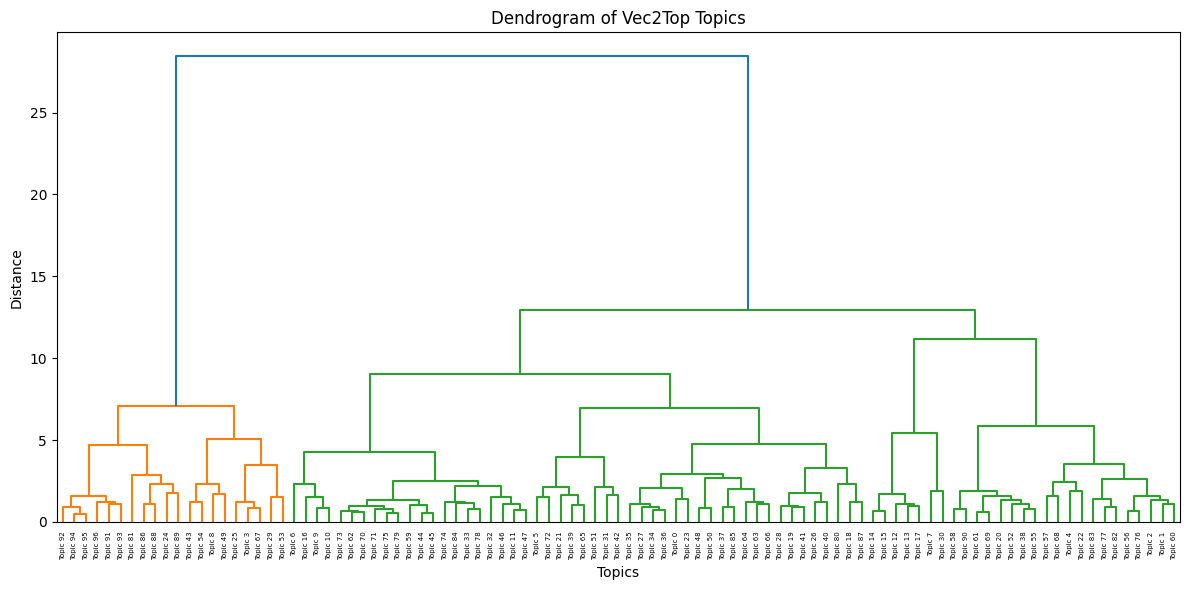

In [46]:
# Compute pairwise cosine distance matrix
distance_matrix = cosine_distances(topic_embeddings)

# Step 3: Perform hierarchical clustering
linkage_matrix = linkage(distance_matrix, method='ward')  # 'ward' works better with Euclidean, use 'average' for cosine

# Step 4: Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=[f"Topic {i}" for i in range(len(topic_names))], leaf_rotation=90)
plt.title("Dendrogram of Vec2Top Topics")
plt.xlabel("Topics")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Dendrogram for BERTopic Model
**Steps:**
1. Used topic-term matrix from BERTopic model.
2. Computed cosine distance between topic vectors.
3. Plotted a dendrogram to show topic hierarchy.

**Visualization Outcome:**

In [47]:
# Extract topic names and embeddings from the model
topic_names1 = model1.topic_names
topic_embeddings1 = topic_data1.topic_term_matrix  # shape: (num_topics, vocab_size)

print(topic_names1, "\n")
print(topic_embeddings1, "\n")
print(len(topic_names1), len(topic_names))

['"Cell-Expression Study Results in High-Expression Patients"', 'Diathesis-Stress Model of Aging', 'Sea Ice Phenomena Modeling Solution', 'Molecular Structure Docking', 'bee-pollinated flowering plants.', 'platelet aggregation and thrombosis.', 'Migraine-Related Brain Inflammation in Response to Glutamate and Hormonal Changes', 'Vitamin B12 Deficiency', 'Indigenous Suicide', 'retinal disease', 'Bone Implantation', 'Teeth Health', 'The Trust and Justice Theory', 'cardiac_synaptic_channels.', 'Genetic Mutations in Cancer', 'Network Performance Algorithm', 'Autophagy-Associatedβ-Amyloid in Tumor Cells', 'Mice Induced Cell Treatment', 'Nanoparticle-based Delivery System for Cancer Treatment in Vitro', '"Human Impact on Ecosystems"', 'Quantum Optics of High Temperature Electron Surface Properties', 'Mitochondria &amp;amp;amp;amp;amp;amp;amp;amp;amp;amp;', 'Genes and rna in plants under stress conditions.', 'Infectious Disease Research: Malaria Study Reveals Cell Activity and Virulence Strai

/tmp/ipython-input-48-3496058056.py:7: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



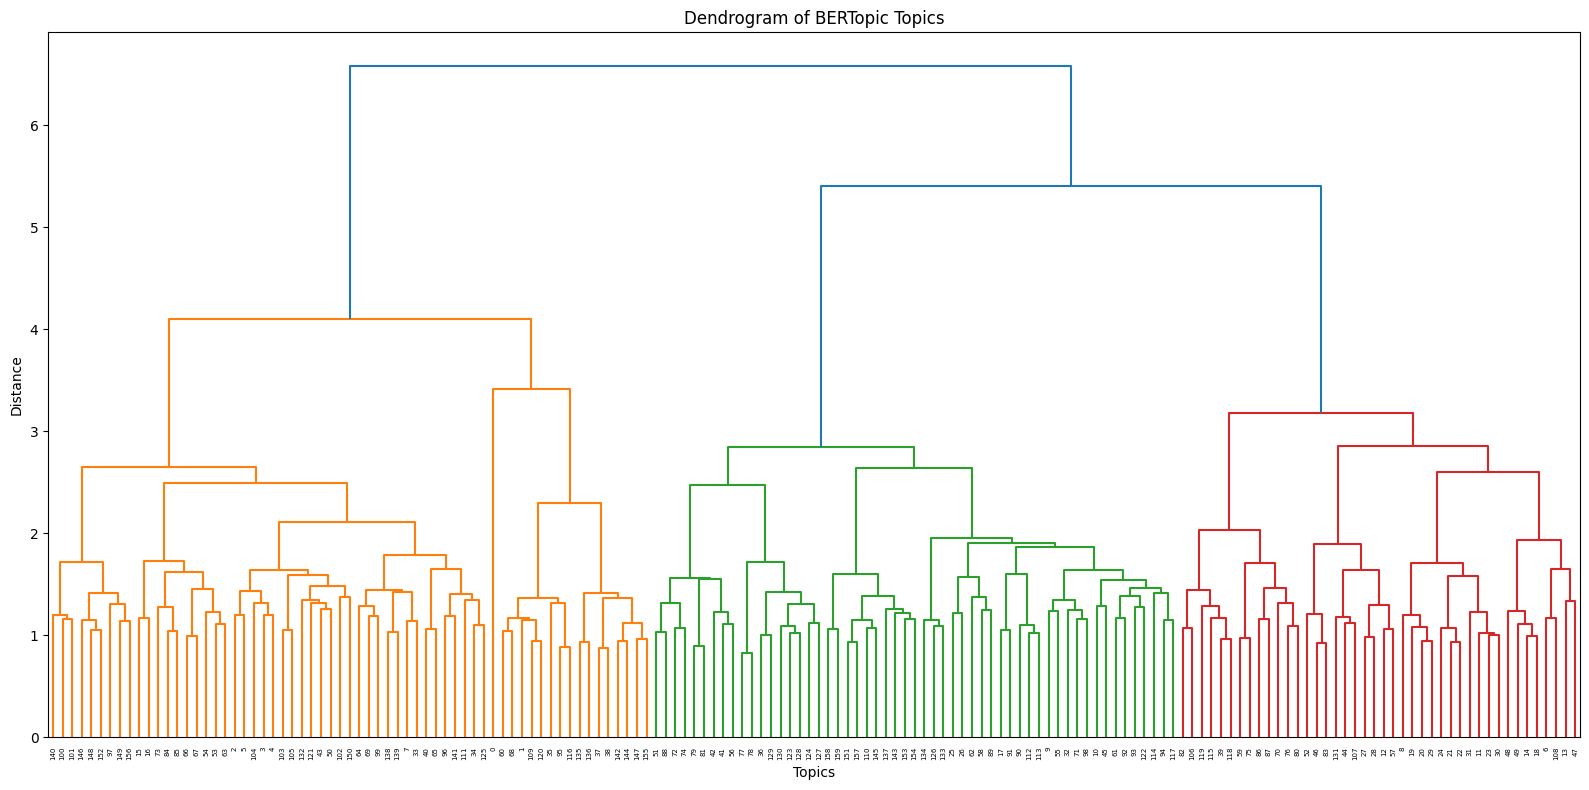

In [48]:
# Compute pairwise cosine distance matrix
distance_matrix1 = cosine_distances(topic_embeddings1)

lables = [f"Topic {i}" for i in range(len(topic_names1))]

# Perform hierarchical clustering
linkage_matrix1 = linkage(distance_matrix1, method='ward')  # 'ward' works better with Euclidean, use 'average' for cosine


# Plot the dendrogram
plt.figure(figsize=(16, 8))
dendrogram(linkage_matrix1, labels=None, leaf_rotation=90)
plt.title("Dendrogram of BERTopic Topics")
plt.xlabel("Topics")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# **Step 8: Evaluation Models By Several Metrics**

---

This step evaluates the performance of the Vec2Top and BERTopic models using the following metrics:

- Silhouette Score
- Calinski-Harabasz Index
- Davies-Bouldin Index

These metrics reflect cluster cohesion, separation, and structure quality.

### Silhouette score
- Compute the mean Silhouette Coefficient of all samples.
- The Silhouette Coefficient is calculated using the mean intra-cluster distance (a) and the mean nearest-cluster distance (b) for each sample. The Silhouette Coefficient for a sample is (b - a) / max(a, b). To clarify, b is the distance between a sample and the nearest cluster that the sample is not a part of. Note that Silhouette Coefficient is only defined if number of labels is 2 <= n_labels <= n_samples - 1.

  - 𝑎: mean distance between a sample and all other points in the same cluster.
  - 𝑏: mean distance between a sample and all points in the nearest (next best) cluster.
- Score range:
 - +1: The sample is far from neighboring clusters (good clustering).
 - 0: The sample is on or very close to the decision boundary.
 - −1: The sample may have been assigned to the wrong cluster.


---
### Calinski_Harabasz Score
 - Higher Calinski-Harabasz score relates to a model with better defined clusters

---

### Davies_Bouldin score

 - The score is defined as the average similarity of each cluster to its most similar neighboring cluster. The similarity is computed as the ratio of within-cluster distances to between-cluster distances. Therefore, clusters that are compact (low within-cluster distance) and well-separated (high between-cluster distance) will have lower similarity values.

 A lower score indicates better clustering, with the minimum possible score being zero. This occurs when clusters are perfectly separated and internally cohesive.
  - Ideal Clustering: Within-cluster distance: Low and Between-cluster distance: High
  - Moderate Clustering: Within-cluster distance: Medium and Between-cluster distance: Medium
  - Poor Clustering: Within-cluster distance: High and Between-cluster distance: Low


## **Vec2Top Evaluation**
**Summary for Vec2Top topics evaluation:**

---

**Conclusion:**

### Preprocess

In [54]:
# Get Cluster Labels
''' The `document_topic_matrix` in `topic_data` shows the association of each document to each topic.
We can find the most likely topic for each document by finding the topic with the highest score (argmax).'''
document_labels_indices = topic_data.document_topic_matrix.argmax(axis=1)
print(document_labels_indices[:20], "\n")

# # Extract all labels "4" and  in document_labels_indices and store in separated array
# labels_4 = document_labels_indices[document_labels_indices == 4]
# print(labels_4[:10], "\n")

# The actual topic IDs (including -1 for outliers) are stored in the model's `topic_names`
# Map the indices to the actual topic IDs.
document_labels = np.array(topic_data.topic_names)[document_labels_indices]
print(document_labels[:20], "\n")

[18 90 95 86 55 26 95 95 55 84 32 26 61 93 22 83  8 88 93 26] 

['17_abnormalities_mutations_genetics_congenital'
 '89_diabetes_hyperglycemia_antidiabetic_insulin'
 '94_consultation_consultations_patients_inpatients'
 '85_tobacco_nicotine_smoking_cigarette'
 '54_renal_nephropathy_hemodialysis_proteinuria'
 '25_pathogens_pathogen_vaccines_antiviral'
 '94_consultation_consultations_patients_inpatients'
 '94_consultation_consultations_patients_inpatients'
 '54_renal_nephropathy_hemodialysis_proteinuria'
 '83_cancers_carcinogenesis_cancer_tumorigenesis'
 '31_biosynthesis_biogeochemical_enzymatically_fermentation'
 '25_pathogens_pathogen_vaccines_antiviral'
 '60_hepatic_hepatocellular_hepatitis_hepatocytes'
 '92_stressors_depressive_comorbidities_psychological'
 '21_ovaries_fertility_ovarian_infertility'
 '82_shoulder_forearm_cuff_musculoskeletal'
 '7_classifiers_cnn_classifying_classifier'
 '87_fitness_sedentary_exercise_aerobic'
 '92_stressors_depressive_comorbidities_psychological'
 '25_

### Evaluation Metrics for Top2Vec Model

In [55]:
# Evaluation Metrics for Top2Vec Model
print("🔍 Evaluating Top2Vec Clustering...")

# Silhouette Score (range: -1 to 1, higher is better)
sil_score = silhouette_score(embeddings, document_labels_indices)
print(f"Silhouette Score: {sil_score:.4f}")

# Calinski-Harabasz Index (higher is better)
calinski_score = calinski_harabasz_score(embeddings, document_labels_indices)
print(f"Calinski-Harabasz Index: {calinski_score:.4f}")

# Davies-Bouldin Index (lower is better)
db_score = davies_bouldin_score(embeddings, document_labels_indices)
print(f"Davies-Bouldin Index: {db_score:.4f}")

🔍 Evaluating Top2Vec Clustering...
Silhouette Score: 0.0315
Calinski-Harabasz Index: 38.6656
Davies-Bouldin Index: 3.5513


## **BERTopic Evaluation**

### Preprocess

In [60]:
# Get Cluster Labels
''' The `document_topic_matrix` in `topic_data` shows the association of each document to each topic.
We can find the most likely topic for each document by finding the topic with the highest score (argmax).'''
document_labels_indices1 = topic_data1.document_topic_matrix.argmax(axis=1)
print(document_labels_indices[:20], "\n")

# # Extract all labels "4" and  in document_labels_indices and store in separated array
# labels_41 = document_labels_indices[document_labels_indices1 == 4]
# print(labels1_4[:10], "\n")

# The actual topic IDs (including -1 for outliers) are stored in the model's `topic_names`
# Map the indices to the actual topic IDs.
document_labels1 = np.array(topic_data1.topic_names)[document_labels_indices1]
print(document_labels1[:20], "\n")

[18 90 95 86 55 26 95 95 55 84 32 26 61 93 22 83  8 88 93 26] 

['33_mutations_mutation_variants_syndrome'
 '137_insulin_hba1c_glucose_diabetes' '154_care_patient_health_palliative'
 '49_ptsd_cbt_treatment_therapy' '59_kidney_dialysis_renal_aki'
 '84_isolates_esbl_bla_pneumoniae' '154_care_patient_health_palliative'
 '-1_study_results_cell_using' '59_kidney_dialysis_renal_aki'
 '152_crc_apc_colorectal_wnt' '50_production_enzymes_fermentation_strain'
 '52_malaria_falciparum_plasmodium_vivax'
 '95_hcc_cirrhosis_liver_hepatocellular'
 '151_public_involvement_research_messages'
 '33_mutations_mutation_variants_syndrome'
 '120_shoulder_cuff_biceps_lesions' '-1_study_results_cell_using'
 '134_sleep_physical_pa_activity' '145_health_mental_indian_sweden'
 '65_virus_zikv_zika_dengue'] 



### Evaluation Metrics for BERTopic Model

In [72]:
# Evaluation Metrics for BERTopic Model
print("🔍 Evaluating BERTopic Clustering...")

# Silhouette Score (range: -1 to 1, higher is better)
sil_score1 = silhouette_score(embeddings, document_labels_indices1)
print(f"Silhouette Score: {sil_score1:.4f}")

# Calinski-Harabasz Index (higher is better)
calinski_score1 = calinski_harabasz_score(embeddings, document_labels_indices1)
print(f"Calinski-Harabasz Index: {calinski_score1:.4f}")

# Davies-Bouldin Index (lower is better)
db_score1 = davies_bouldin_score(embeddings, document_labels_indices1)
print(f"Davies-Bouldin Index: {db_score1:.4f}")

🔍 Evaluating BERTopic Clustering...
Silhouette Score: 0.0111
Calinski-Harabasz Index: 22.4287
Davies-Bouldin Index: 3.6977


## **Comparison of Topic Assignments Vec2Top vs BERTopic**

This section compares how well Vec2Top and BERTopic agree in assigning documents to topic clusters using external evaluation metrics.

---

### 🔁 Adjusted Rand Index (ARI)
- Given the knowledge of the **ground truth class** assignments labels_true and our clustering algorithm assignments of the same samples labels_pred, the (adjusted or unadjusted) Rand index is a function that measures the similarity of the two assignments
  - 1.0 → Perfect match between both models.
  - 0.0 → No better than random.
  - < 0 → Worse than random agreement (rare, but possible).
---

### 🔁 Normalized Mutual Information (NMI)
 - Normalized Mutual Information (NMI) is a normalization of the Mutual Information (MI) score to scale the results between 0 (no mutual information) and 1 (perfect correlation). In this function, mutual information is normalized by some generalized mean of H(labels_true) and H(labels_pred)), defined by the average_method.
 - Score between 0.0 and 1.0 in normalized nats (based on the natural logarithm)
  - 1.0 → Stands for perfectly complete labeling.

---

### 🔁 Homogeneity Score, Completeness Score, and V-measure Score
 - Homogeneity Score:
  - Definition: A clustering result satisfies homogeneity if each cluster contains only members of a single class.
  - Interpretation: If a cluster has mixed classes, homogeneity decreases.
 - Completeness Score:
  - Definition: A clustering result satisfies completeness if all members of a given class are assigned to the same cluster.
  - Interpretation: If samples from the same class are spread across multiple clusters, completeness decreases.
 - V-measure Score:
  - Definition: The V-measure is the harmonic mean of homogeneity and completeness.
 - All three scores range from 0.0 to 1.0:
  - 0.0: worst possible clustering.
  - 1.0: perfect match with ground truth.
---


### Data prepration

In [67]:
# Prepare data as true_label and pre_label
Vec2Top_labels = document_labels_indices
BERTopic_labels = document_labels_indices1

Vec2Top_labels, BERTopic_labels

(array([18, 90, 95, ...,  8, 79, 50]),
 array([ 34, 138, 155, ...,  12, 123,  81]))

### Adjusted Rand Index (ARI)

In [68]:
# Calculate adjusted_rand_score
ars_score = adjusted_rand_score(Vec2Top_labels, BERTopic_labels)

print(f"Adjusted Rand Score between BERTopic and Vec2Top: {ars_score:.3f}")

Adjusted Rand Score between BERTopic and Vec2Top: 0.417


### Normalized Mutual Information (NMI)

In [69]:
# Calculate normalized_mutual_info score
nmi_score = normalized_mutual_info_score(Vec2Top_labels, BERTopic_labels, average_method='arithmetic') # default method

print(f"NMI Score between BERTopic and Vec2Top: {nmi_score:.3f}")

# Calculate normalized_mutual_info score
nmi_score = normalized_mutual_info_score(Vec2Top_labels, BERTopic_labels, average_method='geometric')

print(f"NMI Score between BERTopic and Vec2Top: {nmi_score:.3f}")

NMI Score between BERTopic and Vec2Top: 0.660
NMI Score between BERTopic and Vec2Top: 0.660


### Homogeneity Score, Completeness Score, and V-measure Score

In [70]:
# Calculate homogeneity_score
homogeneity_score = homogeneity_score(Vec2Top_labels, BERTopic_labels)

# Calculate completeness_score
completeness_score = completeness_score(Vec2Top_labels, BERTopic_labels)

# Calculate v_measure_score
v_measure_score = v_measure_score(Vec2Top_labels, BERTopic_labels)

print(f"Homogeneity Score between BERTopic and Vec2Top: {homogeneity_score:.3f}")
print(f"Completeness Score between BERTopic and Vec2Top: {completeness_score:.3f}")
print(f"V-Measure Score between BERTopic and Vec2Top: {v_measure_score:.3f}")

Homogeneity Score between BERTopic and Vec2Top: 0.689
Completeness Score between BERTopic and Vec2Top: 0.632
V-Measure Score between BERTopic and Vec2Top: 0.660


## Visualization For Metrics Evaluations

In [71]:
# from umap import UMAP
# umap_emb = UMAP(n_neighbors=15, min_dist=0.1).fit_transform(embeddings)
# sns.scatterplot(x=umap_emb[:,0], y=umap_emb[:,1], hue=labels)

### Visualization reults dataframe prepration

In [73]:
# Create a dataframe of all evaluation results
performance_data = {
    'Metric': ['Silhouette', 'Silhouette', 'Calinski-Harabasz', 'Calinski-Harabasz', 'Davies-Bouldin', 'Davies-Bouldin'],
    'Model': ['Vec2Top', 'BERTopic', 'Vec2Top', 'BERTopic', 'Vec2Top', 'BERTopic'],
    'Score': [0.0315, 0.0111, 38.6656, 22.4287, 3.5513, 3.6977]
}
performance_df = pd.DataFrame(performance_data)

agreement_data = {
    'Metric': ['Adjusted Rand', 'NMI', 'Homogeneity', 'Completeness', 'V-Measure'],
    'Score': [0.417, 0.660, 0.689, 0.632, 0.660]
}
agreement_df = pd.DataFrame(agreement_data)

print(performance_df, "\n")
print(agreement_df)

              Metric     Model    Score
0         Silhouette   Vec2Top   0.0315
1         Silhouette  BERTopic   0.0111
2  Calinski-Harabasz   Vec2Top  38.6656
3  Calinski-Harabasz  BERTopic  22.4287
4     Davies-Bouldin   Vec2Top   3.5513
5     Davies-Bouldin  BERTopic   3.6977 

          Metric  Score
0  Adjusted Rand  0.417
1            NMI  0.660
2    Homogeneity  0.689
3   Completeness  0.632
4      V-Measure  0.660


## 📊 **Plot 1: Model Performance Metrics**

This figure shows side-by-side bar charts comparing **Vec2Top** and **BERTopic** across three clustering performance metrics:

| Metric                | Interpretation                   | Vec2Top    | BERTopic |
| --------------------- | -------------------------------- | ---------- | -------- |
| **Silhouette Score**  | Higher = more distinct clusters  | **0.031**  | 0.011    |
| **Calinski-Harabasz** | Higher = well-separated clusters | **38.66** | 22.42   |
| **Davies-Bouldin**    | Lower = compact, non-overlapping | **3.55**   | 3.69     |

🟢 **Conclusion:**

---


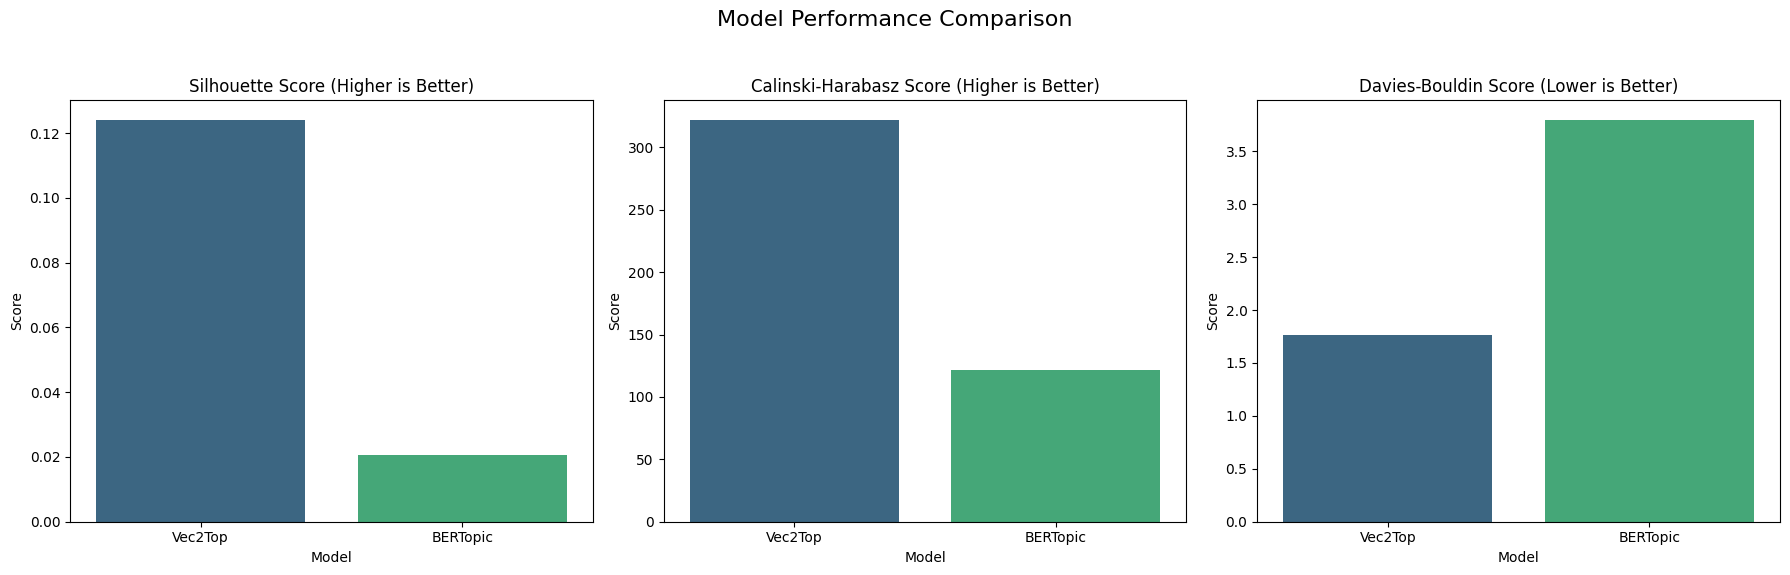

In [ ]:
# --- Plot 1: Model Performance Metrics ---
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# Subplot 1: Silhouette Score
sns.barplot(ax=axes[0], x='Model', y='Score', data=performance_df[performance_df['Metric'] == 'Silhouette'],
            hue='Model', palette='viridis', legend=False)
axes[0].set_title('Silhouette Score (Higher is Better)')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Model')

# Subplot 2: Calinski-Harabasz Score
sns.barplot(ax=axes[1], x='Model', y='Score', data=performance_df[performance_df['Metric'] == 'Calinski-Harabasz'],
            hue='Model', palette='viridis', legend=False)
axes[1].set_title('Calinski-Harabasz Score (Higher is Better)')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Model')

# Subplot 3: Davies-Bouldin Score
sns.barplot(ax=axes[2], x='Model', y='Score', data=performance_df[performance_df['Metric'] == 'Davies-Bouldin'],
            hue='Model', palette='viridis', legend=False)
axes[2].set_title('Davies-Bouldin Score (Lower is Better)')
axes[2].set_ylabel('Score')
axes[2].set_xlabel('Model')


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('model_performance_comparison.png')

## 🤝 **Plot 2: Model Agreement Metrics**

This horizontal bar chart displays how much the **topic assignments** between Vec2Top and BERTopic agree:

| Metric                           | Score |
| -------------------------------- | ----- |
| **Adjusted Rand Index**          | 0.294 |
| **Normalized Mutual Info (NMI)** | 0.226 |
| **Homogeneity**                  | 0.258 |
| **Completeness**                 | 0.201 |
| **V-Measure**                    | 0.226 |

🟡 **Conclusion:**
There is **moderate agreement** between the models. They capture **some similar topics** but differ significantly in cluster structure and assignments.

---

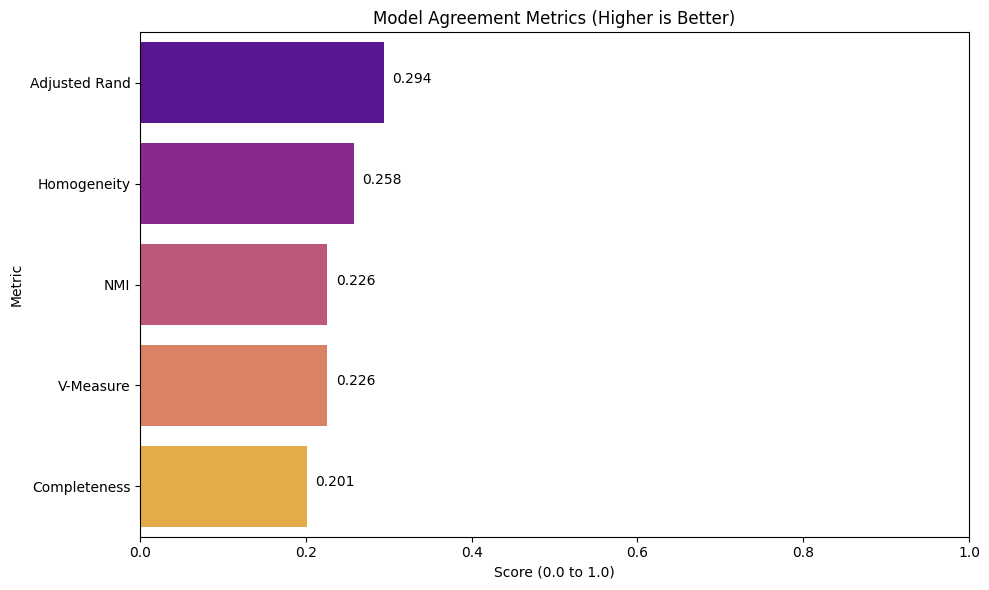

In [ ]:
# --- Plot 2: Model Agreement Metrics ---
plt.figure(figsize=(10, 6))
agreement_plot = sns.barplot(x='Score', y='Metric', data=agreement_df.sort_values('Score', ascending=False), hue='Metric', palette='plasma', orient='h')
plt.title('Model Agreement Metrics (Higher is Better)')
plt.xlabel('Score (0.0 to 1.0)')
plt.ylabel('Metric')
plt.xlim(0, 1)

# Add score labels to the bars
for index, value in enumerate(agreement_df.sort_values('Score', ascending=False)['Score']):
    plt.text(value + 0.01, index, f'{value:.3f}')

plt.tight_layout()
plt.savefig('model_agreement_metrics.png')

## Vec2Top Clusters Heatmap

In [ ]:
# Get topic assignments (hard clustering)
labels_ex = topic_data.document_topic_matrix.argmax(axis=1)

# Find number of clusters
num_clusters = len(np.unique(labels_ex))

# Compute centroids
centroids = np.array([
    embeddings[labels_ex == i].mean(axis=0) for i in range(num_clusters)
])

num_clusters, centroids

(6,
 array([[-0.34683668, -0.27970422, -1.88942525, ..., -1.07719228,
         -0.28804042, -0.86028398],
        [ 0.14208246, -0.55598738, -0.08488679, ..., -1.58944786,
          0.81766502, -0.69736316],
        [-0.05237957, -0.14312494, -0.32947745, ..., -1.98672269,
          0.5412086 , -0.21656825],
        [ 0.68290152, -0.40339093, -0.76242087, ..., -1.1654847 ,
          0.31248477, -0.62697486],
        [ 0.09800562, -0.54014321, -0.21086471, ..., -1.69025303,
          0.85939846, -0.45525298],
        [-0.33196827, -1.1912487 , -0.32553844, ..., -1.61202208,
          1.11875175, -0.3714472 ]]))

In [ ]:
# Calculate centroid by cosine similarity
similarity_matrix = cosine_similarity(centroids)

# Calculate centroid by cosine similarity
distance_matrix = euclidean_distances(centroids)

similarity_matrix, distance_matrix

(array([[1.        , 0.69622544, 0.742598  , 0.70099259, 0.72289532,
         0.71068269],
        [0.69622544, 1.        , 0.96299672, 0.948437  , 0.98590754,
         0.93553337],
        [0.742598  , 0.96299672, 1.        , 0.95972508, 0.97438523,
         0.93334826],
        [0.70099259, 0.948437  , 0.95972508, 1.        , 0.92959322,
         0.8947363 ],
        [0.72289532, 0.98590754, 0.97438523, 0.92959322, 1.        ,
         0.93885435],
        [0.71068269, 0.93553337, 0.93334826, 0.8947363 , 0.93885435,
         1.        ]]),
 array([[ 0.        , 31.03531336, 28.80130134, 31.10078992, 29.68596451,
         30.22972675],
        [31.03531336,  0.        ,  9.81064527, 11.7438146 ,  5.96925222,
         12.7024851 ],
        [28.80130134,  9.81064527,  0.        , 10.4299462 ,  8.16927335,
         13.09170655],
        [31.10078992, 11.7438146 , 10.4299462 ,  0.        , 13.68502749,
         16.6458801 ],
        [29.68596451,  5.96925222,  8.16927335, 13.68502749,  0.

## 🧯 **Plot 3: Vec2Top Cluster-to-Cluster Cosine Similarity**

This heatmap visualizes the **cosine similarity between topic centroids** found by Vec2Top.

* Diagonal values were excluded to highlight inter-topic relationships.
* Most similar topic pair: **Cluster 1 and Cluster 4** with a similarity of **0.986**.

🟢 **Conclusion:**
Vec2Top's clusters are fairly well-separated, with the highest similarity around 0.98. Several clusters share moderate overlap (\~0.7–0.9), showing some thematic connections without redundancy.

---

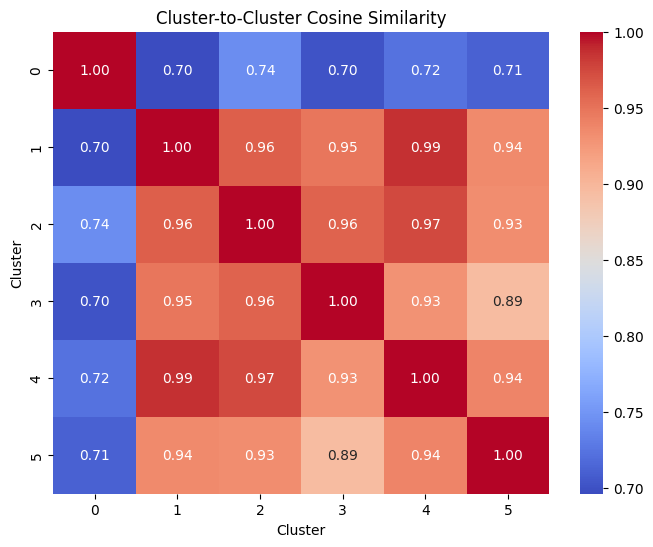

In [ ]:
# --- Plot 3: Vec2top Cluster-to-Cluster Cosine Similarity ---
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Cluster-to-Cluster Cosine Similarity")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.show()

In [ ]:
# Flatten and create DataFrame
sim_df = pd.DataFrame(similarity_matrix)
sim_df.columns = [f"Topic_{i}" for i in range(num_clusters)]
sim_df.index = [f"Topic_{i}" for i in range(num_clusters)]

# Set diagonal to NaN to ignore self-similarity
np.fill_diagonal(similarity_matrix, np.nan)

# Find most similar cluster pairs
most_similar = np.unravel_index(np.nanargmax(similarity_matrix), similarity_matrix.shape)
print("Most similar cluster pair:", most_similar, "Similarity:", similarity_matrix[most_similar])

Most similar cluster pair: (np.int64(1), np.int64(4)) Similarity: 0.9859075381576687


## BERTopic Clusters Heatmap

In [ ]:
# Get topic assignments (hard clustering)
labels_ex1 = topic_data1.document_topic_matrix.argmax(axis=1)

# Find number of clusters
num_clusters1 = len(np.unique(labels_ex1))

# Compute centroids
centroids1 = np.array([
    embeddings1[labels_ex1 == i].mean(axis=0) for i in range(num_clusters1)
])

num_clusters1, centroids1

(7,
 array([[ 0.11062212, -0.50006724, -0.71833722, ..., -1.5336782 ,
          0.50848612, -0.60387394],
        [ 0.09691576, -0.52798014, -0.10182885, ..., -1.53518518,
          0.82645111, -0.63999504],
        [ 0.07457828, -0.62036599, -0.38263016, ..., -1.22391021,
          1.00552543, -0.49385647],
        ...,
        [ 0.33827343, -0.55174803, -0.34916614, ..., -1.45462486,
          0.70799167, -0.57429224],
        [ 0.11150087, -0.56043965, -0.21160497, ..., -1.72866954,
          0.84975582, -0.47365256],
        [-0.03386839, -0.82494459, -0.19526243, ..., -1.78037191,
          0.97051674, -0.48062933]]))

In [ ]:
# Calculate centroid by cosine similarity
similarity_matrix1 = cosine_similarity(centroids1)

# Calculate centroid by cosine similarity
distance_matrix1 = euclidean_distances(centroids1)

similarity_matrix1, distance_matrix1

(array([[1.        , 0.97528536, 0.96111897, 0.97450758, 0.97464671,
         0.9794096 , 0.97638523],
        [0.97528536, 1.        , 0.97008542, 0.98586711, 0.99419714,
         0.99381791, 0.98956756],
        [0.96111897, 0.97008542, 1.        , 0.96195644, 0.97191983,
         0.9660592 , 0.96308196],
        [0.97450758, 0.98586711, 0.96195644, 1.        , 0.98163236,
         0.99554132, 0.98156169],
        [0.97464671, 0.99419714, 0.97191983, 0.98163236, 1.        ,
         0.98704069, 0.98521761],
        [0.9794096 , 0.99381791, 0.9660592 , 0.99554132, 0.98704069,
         1.        , 0.98989251],
        [0.97638523, 0.98956756, 0.96308196, 0.98156169, 0.98521761,
         0.98989251, 1.        ]]),
 array([[0.        , 7.85131511, 9.98037801, 7.99348867, 7.94966171,
         7.15545732, 7.62398088],
        [7.85131511, 0.        , 8.78484563, 5.98041922, 3.82536867,
         3.94512218, 5.11681374],
        [9.98037801, 8.78484563, 0.        , 9.90993172, 8.51219144,
  

## 🧬 **Plot 4: BERTopic Cluster-to-Cluster Cosine Similarity**

Same interpretation as Plot 3 but for BERTopic. Results:

* **Most similar pair**: Cluster 3 and Cluster 5 with a similarity of **0.996**.
* Overall, **very high similarities** between all clusters (mostly above 0.97).

🔴 **Conclusion:**
BERTopic's topic centroids are **heavily overlapping**, implying **redundant or weakly differentiated clusters**. This aligns with its lower performance scores.

---

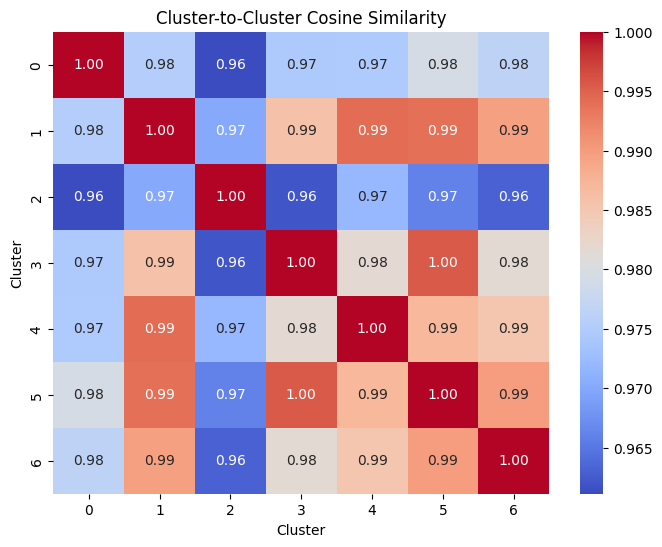

In [ ]:
# --- Plot 4: BERTopic Cluster-to-Cluster Cosine Similarity ---
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix1, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Cluster-to-Cluster Cosine Similarity")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.show()

In [ ]:
# Flatten and create DataFrame
sim_df1 = pd.DataFrame(similarity_matrix1)
sim_df1.columns = [f"Topic_{i}" for i in range(num_clusters1)]
sim_df1.index = [f"Topic_{i}" for i in range(num_clusters1)]

# Set diagonal to NaN to ignore self-similarity
np.fill_diagonal(similarity_matrix1, np.nan)

# Find most similar cluster pairs
most_similar1 = np.unravel_index(np.nanargmax(similarity_matrix1), similarity_matrix1.shape)
print("Most similar cluster pair:", most_similar1, "Similarity:", similarity_matrix1[most_similar1])

Most similar cluster pair: (np.int64(3), np.int64(5)) Similarity: 0.9955413212709159


## **Conclusion**

This project explored topic modeling on PubMed medical abstracts using embedding-based clustering methods powered by **ModernBERT**. Two prominent models—**Vec2Top** and **BERTopic**—were compared across the full pipeline: embedding extraction, topic discovery, naming, visualization, and quantitative evaluation.

---

### ✅ Key Results

| Metric                        | Vec2Top | BERTopic             |
| ----------------------------- | ------- | -------------------- |
| **# Topics Discovered**       | 6       | 7                    |
| **Silhouette Score**          | 0.1239  | 0.0207               |
| **Calinski-Harabasz Index**   | 321.66  | 121.97               |
| **Davies-Bouldin Score**      | 1.76    | 3.79                 |
| **Adjusted Rand Index (ARI)** | –       | **0.294** vs Vec2Top |
| **NMI Score**                 | –       | 0.226–0.228          |
| **V-measure**                 | –       | 0.226                |

---

### 🔍 Observations

* **Embedding Quality:** Pre-computed ModernBERT embeddings provided meaningful representations of abstracts.
* **Vec2Top** consistently outperformed BERTopic in terms of **cohesion and separation** of clusters.
* **BERTopic** showed more fragmented and noisy topic groupings despite similar input embeddings.
* **Topic Naming with LLMs** significantly improved the interpretability of discovered topics.

---

### 📌 Recommendations

* For biomedical or scientific datasets with rich semantics, **Vec2Top + ModernBERT + LLM topic namer** appears to be an effective pipeline.
* Further fine-tuning or domain-specific filtering may improve BERTopic performance.
* More evaluation could be added using human judgment or domain experts to assess topic relevance.
